In [1]:
import os
import sys

# Get the absolute path of the current notebook's directory
notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
sys.path.append(parent_dir)  # Add parent directory to sys.path

# model
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric as tg
import torch_scatter
import e3nn
from e3nn import o3
from typing import Dict, Union

# crystal structure data
from ase import Atom, Atoms
from ase.neighborlist import neighbor_list
from ase.visualize.plot import plot_atoms
palette = ['#43AA8B', '#F8961E', '#F94144']
sub = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")

# data pre-processing and visualization
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pandas as pd
from scipy.interpolate import interp1d
import math
import e3nn.o3 as o3
from e3nn.util.jit import compile_mode
from e3nn.io import CartesianTensor
from e3nn.o3 import wigner_D, so3_generators

# supress error log from font
import logging
logging.getLogger('matplotlib.font_manager').setLevel(level=logging.CRITICAL)
# utilities 
import time
from mendeleev import element
from tqdm import tqdm
from utils.utils_data import (load_data, train_valid_test_split, save_or_load_onehot, build_data, plot_spherical_harmonics_comparison, plot_cartesian_tensor_comparison)
from utils.utils_model_full_tensor import Network, train, evaluate
import wandb

import numpy as np
from ase.io import read  
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import glob
import re
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import torch
from ase import Atoms
from ase.io import write
from tqdm import tqdm
from ase.geometry import cellpar_to_cell, cell_to_cellpar

tqdm.pandas()

plt.rcParams["mathtext.fontset"] = "cm"
fontsize = 18
textsize = 14
sub = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['font.size'] = fontsize-4
plt.rcParams['axes.labelsize'] = fontsize-2
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['legend.fontsize'] = textsize-2
plt.rcParams['text.usetex'] = False
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.dpi'] = 150
bar_format = '{l_bar}{bar:10}{r_bar}{bar:-10b}'
default_dtype = torch.float64
torch.set_default_dtype(default_dtype)

# Create a colormap based on the number of unique symbols
datasets = ['g', 'y', 'r']
colors = dict(zip(datasets, palette))
cmap = mpl.colors.LinearSegmentedColormap.from_list('cmap', [palette[k] for k in [0,2,1]])


# Check device
device = "cuda:1" if torch.cuda.is_available() else "cpu"
print('torch device:' , device)


torch device: cuda:1


# Orthorhmobic $\rightarrow$ Monoclinic

In [2]:
from pymatgen.ext.matproj import MPRester
from pymatgen.analysis.structure_analyzer import SpacegroupAnalyzer
from pymatgen.io.ase import AseAtomsAdaptor

# Replace with your Materials Project API key
API_KEY = "zckQao2291DWQRcIyq96cAwvZH9DAdTy"
# MATERIAL_ID = "mp-7173"  # Cubic used in training
# MATERIAL_ID = "mp-540872" # Cubic not used in training
MATERIAL_ID = "mp-9538" # Orthorhombic not used in training

# MATERIAL_ID = "mp-1084770" # Orthorhombic not used in training




# Step 1: Query the material by Material ID and get the structure
with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(MATERIAL_ID)

# Step 2: Use SpacegroupAnalyzer to refine the structure
sym_prec = 1e-2
spacegroup_analyzer = SpacegroupAnalyzer(structure, symprec=sym_prec)
refined_structure = spacegroup_analyzer.get_refined_structure()

# Step 3: Convert the refined structure to an ASE Atoms object
ase_atoms = AseAtomsAdaptor.get_atoms(refined_structure)
crystal_system = spacegroup_analyzer.get_crystal_system()

# Optional: Print some details to verify
print(f"Material ID: {MATERIAL_ID}")
print(f"Spacegroup (before refinement): {spacegroup_analyzer.get_space_group_symbol()}")
print(f"Spacegroup (after refinement): {SpacegroupAnalyzer(refined_structure).get_space_group_symbol()}")
print(f"Number of atoms in ASE object: {len(ase_atoms)}")
print(f"Chemical symbols: {ase_atoms.get_chemical_symbols()}")
print(f"Cell parameters: {ase_atoms.cell}")


/home/angush/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Retrieving MaterialsDoc documents: 100%|██████████| 1/1 [00:00<00:00, 30174.85it/s]

Material ID: mp-9538
Spacegroup (before refinement): Pmn2_1
Spacegroup (after refinement): Pmn2_1
Number of atoms in ASE object: 16
Chemical symbols: ['Ag', 'Ag', 'Ag', 'Ag', 'Ag', 'Ag', 'As', 'As', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S']
Cell parameters: Cell([7.8419814500000005, 6.9463108, 6.63335771])


In [3]:
def apply_monoclinic_strain(atoms, angle_strain_deg):
    """
    Apply a monoclinic distortion by changing the beta angle
    (the angle between a and c axis) while keeping lengths fixed.

    Parameters:
    - atoms: ASE Atoms object
    - angle_strain_deg: amount to change beta angle, in degrees
      (e.g., +1° would make beta = 91° if starting from 90°)
    """
    strained = atoms.copy()
    cell = strained.get_cell()
    
    # Convert to cell parameters: [a, b, c, alpha, beta, gamma]
    cellpar = cell_to_cellpar(cell)

    # Apply strain to the beta angle (keep others)
    cellpar[4] += angle_strain_deg  # beta index is 4

    # Build new cell
    new_cell = cellpar_to_cell(cellpar)

    # Set the new strained cell
    strained.set_cell(new_cell, scale_atoms=True)
    return strained


def build_strained_dataset(
    base_atoms, strain_list, MATERIAL_ID, crystal_system, new_x, dummy_tensor, build_data_fn, scale_data, r_max,
    type_onehot, mass_onehot, dipole_onehot, radius_onehot, type_encoding
):
    all_rows = []
    os.makedirs("../POSCARs", exist_ok=True)

    for strain in strain_list:
        strained_atoms = apply_monoclinic_strain(base_atoms, strain)

        poscar_name = f"../POSCARs/POSCAR_{MATERIAL_ID}_strain_{int(strain)}"
        write(poscar_name, strained_atoms, format="vasp")
        
        row = {
            "mp_id": f"{MATERIAL_ID}_strain_{strain}",
            "formula": strained_atoms.get_chemical_formula(),
            "symmetrized_structure": strained_atoms,
            "energies_interp": new_x,
            "imag_Permittivity_Matrices_interp": dummy_tensor.copy(),
            "crystal_system": crystal_system
        }

        # Cartesian → Spherical (zero tensor placeholder)
        x = CartesianTensor("ij=ji")  # Symmetric rank-2 tensor
        place_holder = torch.from_numpy(dummy_tensor.copy()).float()
        sph_coefs_tensor = x.from_cartesian(place_holder)
        row["sph_coefs"] = sph_coefs_tensor.cpu().numpy()

        all_rows.append(row)

    df_strained = pd.DataFrame(all_rows)

    # Build graphs
    df_strained["data"] = df_strained.progress_apply(
        lambda x: build_data_fn(
            x, "sph_coefs", scale_data,
            type_onehot, mass_onehot, dipole_onehot, radius_onehot,
            type_encoding, r_max
        ), axis=1
    )

    return df_strained


In [4]:
# Parameters
energy_min = 0  # eV
energy_max = 30  # eV
nstep = 300
new_x = np.linspace(energy_min, energy_max, nstep)
dummy_tensor = np.zeros((nstep, 3, 3))

type_onehot, mass_onehot, dipole_onehot, radius_onehot, type_encoding = save_or_load_onehot()

# Find the scaling value
# scale_data = 9.660251973905062
scale_0e = 12.0045
scale_2e = 2.4356
scale_data = 1
n_train = 43.404443289593345


r_max = 6. # cutoff radius

# angle_list = np.arange(0, 10, 0.5)  # [-2.0, -1.5, ..., +2.0] degrees relative to 90°
angle_list = np.linspace(0, 24, 13)  # [-2.0, -1.5, ..., +2.0] degrees relative to 90°
# angle_list = np.linspace(0, 10, 6) 

# print(len(angle_list))
df = build_strained_dataset(
    base_atoms=ase_atoms,
    strain_list=angle_list,
    MATERIAL_ID=MATERIAL_ID,
    crystal_system="orthorhombic",
    new_x=new_x,
    dummy_tensor=dummy_tensor,
    build_data_fn=build_data,
    scale_data=scale_data,
    r_max=r_max,
    type_onehot=type_onehot,
    mass_onehot=mass_onehot,
    dipole_onehot=dipole_onehot,
    radius_onehot=radius_onehot,
    type_encoding=type_encoding
)

run_time = '250909'


class PeriodicNetwork(Network):
    def __init__(self, in_dim, em_dim , **kwargs):            
        # override the `reduce_output` keyword to instead perform an averge over atom contributions    
        self.pool = False
        if kwargs['reduce_output'] == True:
            kwargs['reduce_output'] = False
            self.pool = True
            
        super().__init__(**kwargs)

        self.em_z = nn.Linear(in_dim, em_dim)    #Linear layer for atom type
        self.em_x = nn.Linear(in_dim, em_dim)    #Linear layer for atom type

    def forward(self, data: Union[tg.data.Data, Dict[str, torch.Tensor]]) -> torch.Tensor:
        data.z = F.relu(self.em_z(data.z))
        data.x = F.relu(self.em_x(data.x))

        output = super().forward(data)
        if self.pool == True:
            output = torch_scatter.scatter_mean(output, data.batch, dim=0)  # take mean over atoms per example
        return output

out_dim = len(df.iloc[0]['energies_interp'])      # about 200 points
em_dim = 128
lmax = 2
use_batch_norm = False
dropout_prob=0
batch_size = 12 # 8 for ori. 12 for unconv.
lr = 1e-2
# layers = 4
layers = 2 # for uncionverged model
model = PeriodicNetwork(
    in_dim=118,
    em_dim=em_dim,
    irreps_in=str(em_dim)+"x0e",
    irreps_out=str(out_dim)+"x0e +" + str(out_dim) + "x2e",
    # irreps_out = "1800x0e",
    irreps_node_attr=str(em_dim)+"x0e",
    layers=layers,
    mul=32,
    lmax=lmax,
    max_radius=r_max,
    num_neighbors=n_train,
    reduce_output=True,
    dropout_prob=dropout_prob,
    use_batch_norm = use_batch_norm
)
# run_name = f'scalar_model_{run_time}_Lmax=3'
# run_name = f'tensor_model_{run_time}_Lmax=4_with_b'
# run_name = f'saved_test_{run_time}_Lmax={lmax}_Lr_0.01_with_individual_b'
# run_name = f'revision_{run_time}_Lmax_{lmax}_Lr_{lr}_bs_{batch_size}_em_{em_dim}_layers_{layers}'
run_name = f"unconverged_TSENN-B_250922_Lmax_2_Lr_0.01_bs_12_em_128_layers_2_mul_32"


wandb.init(
    project="Prediction",  # Change this to your project name
    name=run_name,  # Unique identifier for this run
    config={
    }
)

# predict on all data
model.load_state_dict(torch.load('../model/'+run_name + '_best.torch', map_location=device)['state'])
model.pool = True

dataloader = tg.loader.DataLoader(df['data'].values, batch_size=64)
df['mse_sph'] = 0.
df['y_pred_sph'] = np.empty((len(df), 0)).tolist()

model.to(device)
model.eval()

predictions = [] 
i0 = 0
with torch.no_grad():
    for i, d in tqdm(enumerate(dataloader), total=len(dataloader), bar_format=bar_format):
        d.to(device)
        output = model(d)
        
        irreps_0e = model.irreps_out.count(o3.Irrep("0e"))
        irreps_2e = model.irreps_out.count(o3.Irrep("2e")) * 5
        out_dim = model.irreps_out.count(o3.Irrep("0e")) 
        
        output_0e = output[:, :irreps_0e] * scale_0e
        output_2e = output[:, irreps_0e:irreps_0e + irreps_2e].contiguous().view(output.shape[0], out_dim, 5) *scale_2e

        y_0e = d.y[:, :, 0].view(d.y.shape[0], out_dim) * scale_0e
        y_2e = d.y[:, :, 1:].view(d.y.shape[0], out_dim, 5) * scale_2e

        loss_0e = F.mse_loss(output_0e, y_0e) 
        loss_2e = F.mse_loss(output_2e, y_2e)   
        loss = loss_0e + loss_2e
        
        combined_output = torch.cat([output_0e.unsqueeze(2), output_2e], dim=2)  
        predictions.append(combined_output.cpu())

        for batch_idx in range(d.y.shape[0]):
            df.loc[i0 + batch_idx, 'y_pred_sph'] = [combined_output[batch_idx].cpu().numpy()]
            df.loc[i0 + batch_idx, 'mse_sph'] = loss.cpu().numpy() * scale_data

        i0 += d.y.shape[0]
        

column = 'imag_Permittivity_Matrices_interp'

df['y_pred_sph'] = df['y_pred_sph'].map(lambda x: x[0]) * scale_data


sph_tensors = torch.tensor(np.stack(df['y_pred_sph'].values))  

x = CartesianTensor("ij=ji")  # Symmetric rank-2 tensor
cart_tensors = x.to_cartesian(sph_tensors)

# Assign back to the DataFrame
df['y_pred_cart'] = list(cart_tensors.numpy())  # Convert back to list of NumPy arrays
wandb.finish()


Loading existing data...


100%|██████████| 13/13 [00:00<00:00, 164.36it/s]
wandb: Currently logged in as: hsu-ting (hsu-ting-northeastern-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


100%|██████████| 1/1 [00:00<00:00,  1.79it/s]


/tmp/ipykernel_10599/1782207505.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(
/tmp/ipykernel_10599/1782207505.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


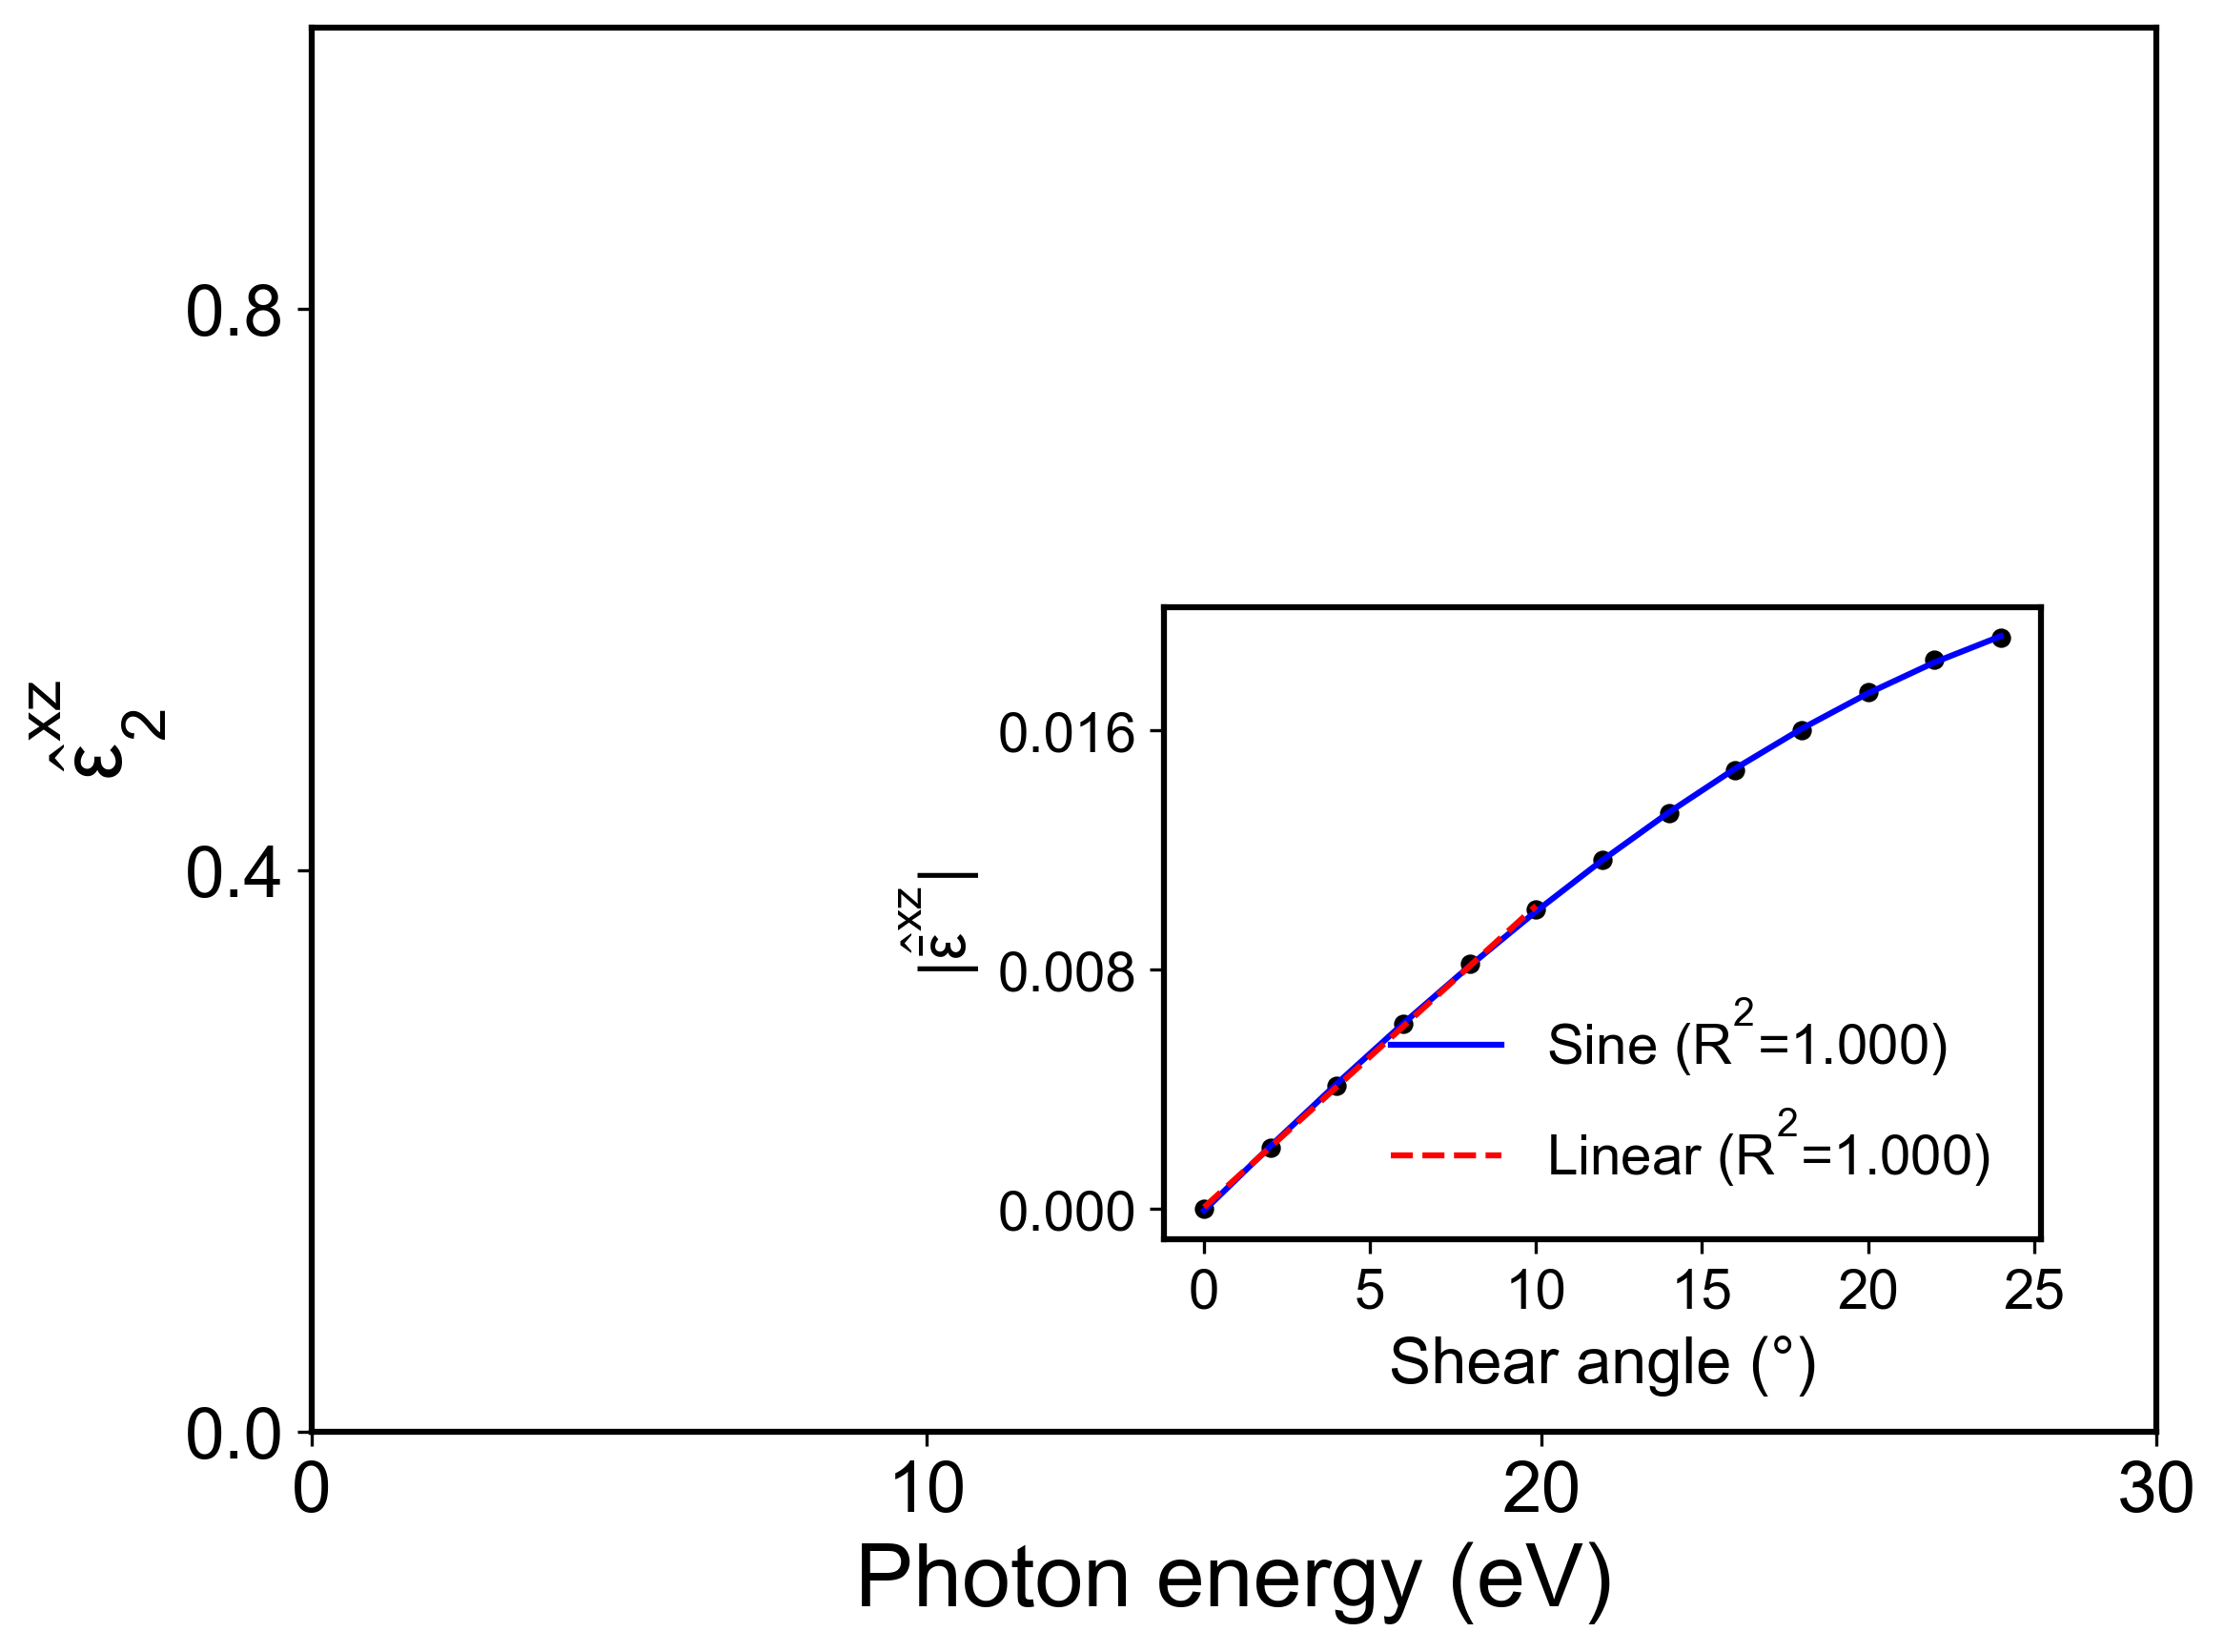

In [5]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Δxz from predicted cartesian
df["delta_zz_xx"] = df["y_pred_cart"].map(lambda x: x[:, 0, 2])
# df["delta_zz_xx"] = df["y_pred_cart"].map(lambda x: x[:, 0, 0] - x[:, 2, 2])


# Plot spectra for each strained structure
for index, row in df.iterrows():
    strain_str = re.findall(r"strain_(-?\d+\.?\d*)", row["mp_id"])
    strain_label = f"{float(strain_str[0]):.1f}°" if strain_str else row["mp_id"]
    # strain_label = f"{float(strain_str[0]):.1f} %" if strain_str else row["mp_id"]


    energy = row["energies_interp"]
    delta = row["delta_zz_xx"]

    # ax.plot(energy, delta, label=strain_label)

ax.set_xlabel("Photon energy (eV)", fontsize=fontsize + 4)
ax.set_ylabel(r"$\hat{\epsilon}^{xz}_2$", fontsize=fontsize + 4)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
# ax.set_ylabel(r"$\hat\epsilon_{xx} - \hat\epsilon_{zz}$", fontsize=fontsize + 4)
x_ticks_main = np.linspace(df.iloc[0]["energies_interp"].min(),
                           df.iloc[0]["energies_interp"].max(), 4)
ax.set_xticks(x_ticks_main)
ax.set_xticklabels([f"{int(x)}" for x in x_ticks_main])
# Legend inside main plot
ax.legend(
    loc="upper right",
    frameon=False,
    ncol = 3, 
    fontsize= fontsize - 6
)
# ymin, ymax = ax.get_ylim()
# ax.set_ylim(ymin, ymax * 1.25) 
# ax.set_ylim(ymin - (ymax - ymin) * 0.25, ymax)
# =========================
# Inset: Strain–anisotropy fits
# =========================
df["delta_zz_xx"] = df["y_pred_cart"].map(lambda x: np.abs(x[:, 0, 2]))
# df["delta_zz_xx"] = df["y_pred_cart"].map(lambda x: np.abs(x[:, 0, 0] - x[:, 2, 2]))
strain_values, mean_anisotropies = [], []
for index, row in df.iterrows():
    strain_str = re.findall(r"strain_(-?\d+\.?\d*)", row["mp_id"])
    if strain_str:
        strain = float(strain_str[0])
        mean_aniso = np.mean(row["delta_zz_xx"])
        strain_values.append(strain)
        mean_anisotropies.append(mean_aniso)

strain_values, mean_anisotropies = zip(*sorted(zip(strain_values, mean_anisotropies)))
strain_values = np.array(strain_values).reshape(-1, 1)
mean_anisotropies = np.array(mean_anisotropies)

# Linear fit (0–10°)
lin_mask = (strain_values.flatten() >= -0.1) & (strain_values.flatten() <= 10)
x_lin = strain_values[lin_mask].reshape(-1, 1)
y_lin = mean_anisotropies[lin_mask]
model = LinearRegression().fit(x_lin, y_lin)
pred_lin = model.predict(x_lin)
r2_lin = r2_score(y_lin, pred_lin)

# Sine fit (full range)
def sine_func(x, A, B, phi, C):
    return A * np.sin(B * x + phi) + C

x_sin, y_sin = strain_values.flatten(), mean_anisotropies
A0 = (y_sin.max() - y_sin.min()) / 2
B0, phi0, C0 = np.pi / 180.0, 0, y_sin.mean()
popt_sin, _ = curve_fit(sine_func, x_sin, y_sin, p0=[A0, B0, phi0, C0], maxfev=100000)
pred_sin = sine_func(x_sin, *popt_sin)
r2_sin = r2_score(y_sin, pred_sin)

# Create inset
ax_inset = inset_axes(ax, width="50%", height="45%", loc="lower right", bbox_to_anchor=(0.0, 0.12, 0.95, 1), bbox_transform=ax.transAxes)

ax_inset.scatter(strain_values, mean_anisotropies, color='k', s=15)
ax_inset.plot(x_sin, pred_sin, 'b', linewidth=1.5, label=fr"Sine ($R^2$={r2_sin:.3f})")
ax_inset.plot(x_lin, pred_lin, 'r--', linewidth=1.5, label=fr"Linear ($R^2$={r2_lin:.3f})")
ax_inset.yaxis.set_major_locator(plt.MaxNLocator(3))   # at most 3 ticks on y-axis
ax_inset.xaxis.set_major_locator(plt.MaxNLocator(6))   # clean x-axis ticks

# Optional: smaller font + scientific notation for y-axis
ax_inset.tick_params(axis="both", which="major", labelsize=7)
ax_inset.set_xlabel("Shear angle (°)", fontsize=fontsize -2)
ax_inset.set_ylabel(r"$|\hat{\bar\epsilon}^{xz}|$", fontsize=fontsize -2)
# ax_inset.set_ylabel(r"MAE($\hat\epsilon_{xx}$, $\hat\epsilon_{zz}$)", fontsize=fontsize -4)

ax_inset.tick_params(axis="both", which="major", labelsize=fontsize -4)
ax_inset.legend(frameon=False, fontsize=fontsize -4, loc="lower right")

plt.tight_layout()
plt.show()

In [6]:
def process_all_folders(root_folder):
    all_data = []

    for dirpath, dirnames, filenames in os.walk(root_folder):
        dirnames[:] = [d for d in dirnames if not d.endswith("_rst")]
        cif_file = None
        for file in filenames:
            if file.endswith(".cif"):
                cif_file = os.path.join(dirpath, file)
                break

        permittivity_file = os.path.join(dirpath, "permittivity_kgd_0.05.dat")
        if not cif_file or not os.path.exists(permittivity_file):
            # print(f"Skipping {dirpath}: Missing .cif or permittivity.dat")
            continue

        try:
            structure = read(cif_file)
        except Exception as e:
            print(f"Error reading {cif_file}: {e}")
            continue

        a, b, c = structure.cell.lengths()   # Å
        alpha, beta, gamma = structure.cell.angles()  # degrees
        formula = structure.get_chemical_formula()

        try:
            permittivity_data = np.loadtxt(permittivity_file)
        except Exception as e:
            print(f"Error reading {permittivity_file}: {e}")
            continue

        omega = permittivity_data[:, 0]
        permittivity = permittivity_data[:, 1:]

        all_data.append({
            "folder": dirpath,
            "structure": structure,
            "formula": formula,
            "omega": omega,
            "permittivity": permittivity,
            "a": a, "b": b, "c": c,
            "alpha": alpha, "beta": beta, "gamma": gamma
        })

    return pd.DataFrame(all_data)


def store_permittivity_matrices(result_df):
    matrices = []

    for _, row in result_df.iterrows():
        permittivity = row['permittivity']
        real_part = permittivity[:, 0::2]
        imag_part = permittivity[:, 1::2]

        omega_count = permittivity.shape[0]
        real_matrices = real_part.reshape((omega_count, 3, 3))
        imag_matrices = imag_part.reshape((omega_count, 3, 3))

        matrices.append({
            "folder": row["folder"],
            "formula": row["formula"],
            "structure": row["structure"],
            "omega": row["omega"],
            "real_Permittivity_Matrices": real_matrices,
            "imag_Permittivity_Matrices": imag_matrices,
            "a": row["a"], "b": row["b"], "c": row["c"],
            "alpha": row["alpha"], "beta": row["beta"], "gamma": row["gamma"]
        })

    return pd.DataFrame(matrices)


# Example usage
root_folder = "/home/angush/TSENN/block_2025-09-24-02-04-04-649869"
result_df = process_all_folders(root_folder)
matrices_df = store_permittivity_matrices(result_df)

/home/angush/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/ase/io/cif.py:408: UserWarning: crystal system 'triclinic' is not interpreted for space group Spacegroup(1, setting=1). This may result in wrong setting!
  warnings.warn(


/tmp/ipykernel_10599/1154187988.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


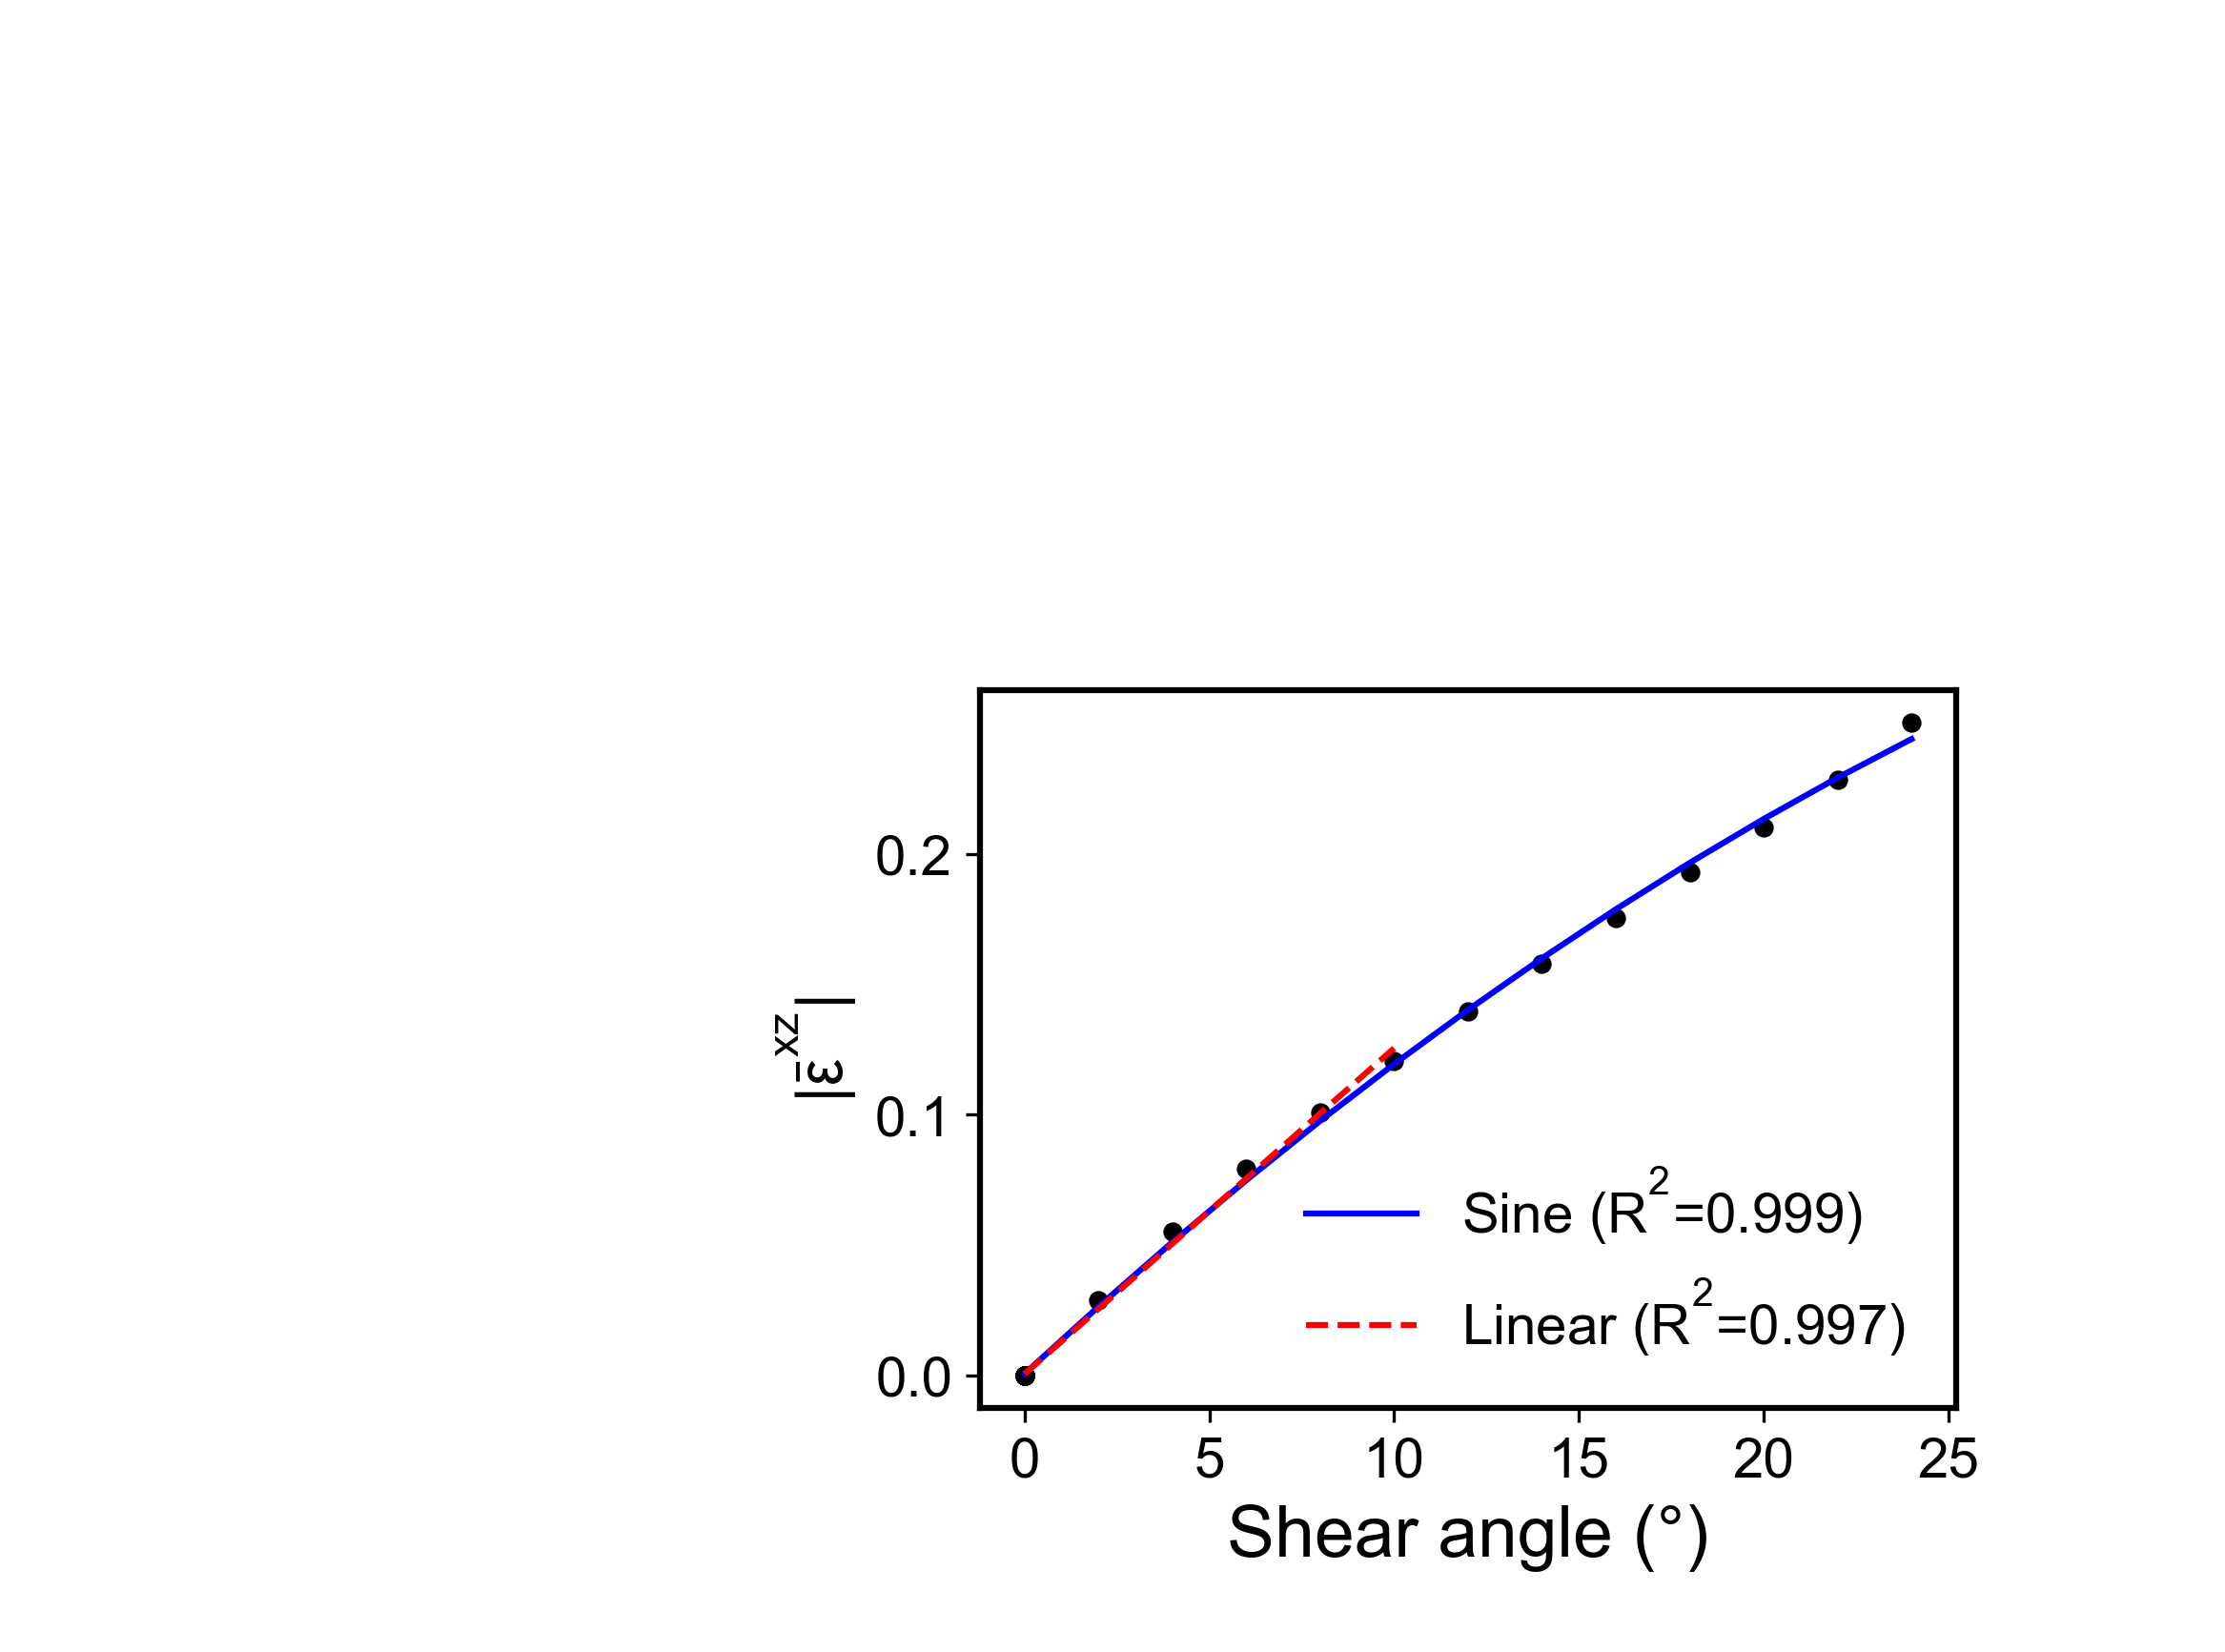

In [7]:
# Extract shear angle (beta - 90) and anisotropy
strain_values = []
mean_anisotropies = []

for _, row in matrices_df.iterrows():
    shear_angle = row["beta"] - 90.0  # deviation from orthogonal
    mean_aniso = np.mean(np.abs(row["imag_Permittivity_Matrices"][:, 0, 2]))
    strain_values.append(shear_angle)
    mean_anisotropies.append(mean_aniso)
    
matrices_df["shear_angle"] = matrices_df["beta"] - 90.0

# Convert to arrays
strain_values = np.array(strain_values)
mean_anisotropies = np.array(mean_anisotropies)

# Sort by angle for cleaner plotting
sort_idx = np.argsort(strain_values)
strain_values = strain_values[sort_idx].reshape(-1, 1)
mean_anisotropies = mean_anisotropies[sort_idx]

# ----------------------
lin_mask = (strain_values.flatten() >= 0) & (strain_values.flatten() <= 10)
x_lin = strain_values[lin_mask].reshape(-1, 1)
y_lin = mean_anisotropies[lin_mask]

model = LinearRegression()
model.fit(x_lin, y_lin)
pred_lin = model.predict(x_lin)
r2_lin = r2_score(y_lin, pred_lin)

# ----------------------
# Region 2: Sine fit (entire range)
# ----------------------
x_sin = strain_values.flatten()
y_sin = mean_anisotropies

def sine_func(x, A, B, phi, C):
    return A * np.sin(B * x + phi) + C

A0 = (y_sin.max() - y_sin.min()) / 2
B0 = np.pi / 180.0
phi0 = 0
C0 = y_sin.mean()
p0 = [A0, B0, phi0, C0]

popt_sin, _ = curve_fit(sine_func, x_sin, y_sin, p0=p0, maxfev=100000)
pred_sin = sine_func(x_sin, *popt_sin)
r2_sin = r2_score(y_sin, pred_sin)

# ----------------------
# Plot
# ----------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Hide the main (empty) axis so you just get a white frame
ax.axis("off")

# Create inset occupying part of the white frame
ax_inset = inset_axes(ax, width="50%", height="45%", loc="lower right", bbox_to_anchor=(0.0, 0.12, 0.9, 1), bbox_transform=ax.transAxes)

ax_inset.scatter(strain_values, mean_anisotropies, color='k', s=15)
ax_inset.plot(x_sin, pred_sin, 'b', linewidth=1.5, label=fr"Sine ($R^2$={r2_sin:.3f})")
ax_inset.plot(x_lin, pred_lin, 'r--', linewidth=1.5, label=fr"Linear ($R^2$={r2_lin:.3f})")
ax_inset.yaxis.set_major_locator(plt.MaxNLocator(3))   # at most 3 ticks on y-axis
ax_inset.xaxis.set_major_locator(plt.MaxNLocator(6))   # clean x-axis ticks

# Optional: smaller font + scientific notation for y-axis
ax_inset.tick_params(axis="both", which="major", labelsize=7)
ax_inset.set_xlabel("Shear angle (°)", fontsize=fontsize)
ax_inset.set_ylabel(r"$|{\bar\epsilon}^{xz}|$", fontsize=fontsize -2)
# ax_inset.set_ylabel(r"MAE($\hat\epsilon_{xx}$, $\hat\epsilon_{zz}$)", fontsize=fontsize -4)

ax_inset.tick_params(axis="both", which="major", labelsize=fontsize -4)
ax_inset.legend(frameon=False, fontsize=fontsize -4, loc="lower right")

plt.tight_layout()
plt.show()